In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import pydmd, _utils, STQP

from matplotlib.patches import Circle
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error

import warnings
warnings.simplefilter('ignore')
np.random.seed(42)

# Set font sizes
AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
LEGEND_SIZE = 12

In [2]:
nx = 449
ny = 199
xlim = 9
ylim = 4
xmesh, ymesh = np.meshgrid(np.linspace(0, xlim, nx+1),  # nx+1 points
                           np.linspace(0, ylim, ny+1))  # ny+1 points
data = scipy.io.loadmat('Data/VORTALL.mat')

In [3]:
U = data['VORTALL']
sigma = 0
noise = np.random.randn(U.shape[0], U.shape[1])*sigma
U_noise = U + noise

train_len = 50
X = U_noise[:, :train_len]
if sigma!='salt':
    print(f'Signal-to-noise ratio: {_utils.compute_signal2noise(X, noise[:, :train_len])}')
    
U3d = U.reshape(nx, ny, U.shape[-1])
U3d_noise = U_noise.reshape(nx, ny, U_noise.shape[-1])

Signal-to-noise ratio: inf


In [4]:
print(f'Rank: {np.linalg.matrix_rank(U[:, :train_len])}')
print(_utils.compute_energy_rank(U[:, :train_len], energy_threshold=0.99))
print(f'Rank: {np.linalg.matrix_rank(U_noise[:, :train_len])}')
print(_utils.compute_energy_rank(U_noise[:, :train_len], energy_threshold=0.99))

Rank: 50
Singular values: [2065.89181653  773.71071457  686.01781893  269.21182005  267.19950928
  204.38861506  193.27452919   83.7321961    80.73380871   43.58143419]...
Cumulative energy at rank 7: 0.9967
7
Rank: 50
Singular values: [2065.89181653  773.71071457  686.01781893  269.21182005  267.19950928
  204.38861506  193.27452919   83.7321961    80.73380871   43.58143419]...
Cumulative energy at rank 7: 0.9967
7


In [5]:
rank = -1 
mus = np.geomspace(1e-8, 1e0, num=5)
mus.sort()
stqp_list = dict()
X0 = U[:, :train_len]
X = U_noise[:, :train_len] 
tik = 1e-8

exact_dmd0 = pydmd.DMD(svd_rank=rank).fit(X0)
print('Exact DMD (clearn)')
print(mean_squared_error(exact_dmd0.reconstructed_data.real, X0))

exact_dmd = pydmd.DMD(svd_rank=rank).fit(X)
print('Exact DMD')
print(mean_squared_error(exact_dmd.reconstructed_data.real, X))

for mu in mus:
    stqp_list[f'mu_{mu}'] = STQP.stqpDMD(svd_rank=rank, mu=mu, tikhonov_regularization=0,
                                         use_csc=False, verbose=False).fit(X)
    print(f'Sparse DMD (mu = {mu})')
    print(mean_squared_error(stqp_list[f'mu_{mu}'].reconstructed_data.real, X))

Exact DMD (clearn)
5.828900687826099e-13
Exact DMD
5.828900687826099e-13
Sparse DMD (mu = 1e-08)
9.99759217250716e-12
Sparse DMD (mu = 1e-06)
9.99759217250716e-12
Sparse DMD (mu = 0.0001)
9.99759217250716e-12
Sparse DMD (mu = 0.01)
6.617865591925823e-10
Sparse DMD (mu = 1.0)
9.71620895920217e-06


In [6]:
print(_utils.count_nnz(exact_dmd0._b))
print(_utils.count_nnz(exact_dmd._b))
for mu in mus:
    print(_utils.count_nnz(stqp_list[f'mu_{mu}']._b))

49
49
49
49
49
31
17


In [7]:
stqp_dmd = stqp_list['mu_1.0']
print("Eigenvalues equal:", np.allclose(exact_dmd.eigs, stqp_dmd.eigs))
print("Modes equal:", np.allclose(exact_dmd.modes, stqp_dmd.modes))

Eigenvalues equal: True
Modes equal: False


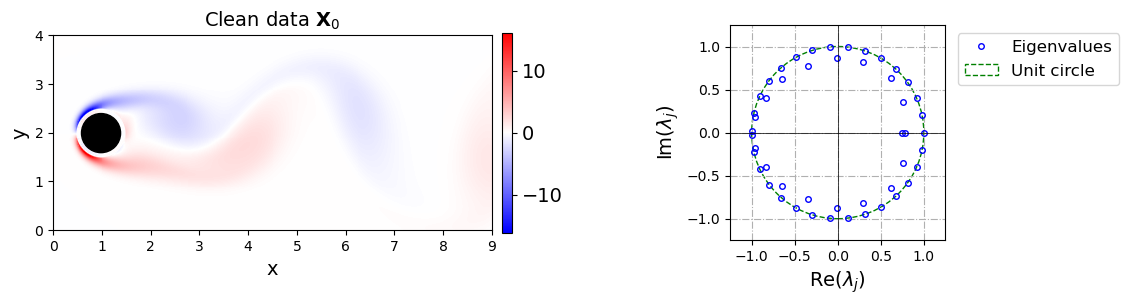

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
ax = axes[0]

vmax = np.absolute(U3d_noise[:,:,0]).max()*0.9
c = ax.pcolor(xmesh, ymesh, U3d_noise[:,:,0].T,
             cmap='bwr', shading='flat', vmin=-vmax, vmax=vmax)

ax.set_aspect('equal')
ax.set_xlabel("x", fontsize=AXIS_LABEL_SIZE)
ax.set_ylabel("y", fontsize=AXIS_LABEL_SIZE)

cx = xmesh[99, 49]
cy = ymesh[99, 49]
radius = 20 * (xmesh[0,1] - xmesh[0,0])
circle = Circle((cx, cy), radius, color='black', zorder=10)
ax.add_patch(circle)

cbar = fig.colorbar(c, ax=ax, shrink=0.93, pad=0.02)
cbar.ax.tick_params(labelsize=AXIS_LABEL_SIZE)
ax.set_title(r"Clean data ${\mathbf{X}}_0$", fontsize=AXIS_LABEL_SIZE)

ax = axes[1]

ax.plot(stqp_dmd.eigs.real, stqp_dmd.eigs.imag, "bo", markerfacecolor='none', markersize=4, label="Eigenvalues")
limit = 1.25
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5)

unit_circle = plt.Circle((0, 0), 1,color='green', fill=False,linestyle='--', label='Unit circle')
ax.add_artist(unit_circle)

ax.set_aspect('equal')
ax.grid(True, linestyle='-.')
ax.set_xlabel("Re($\lambda_j$)", fontsize=AXIS_LABEL_SIZE)
ax.set_ylabel("Im($\lambda_j$)", fontsize=AXIS_LABEL_SIZE)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.show()

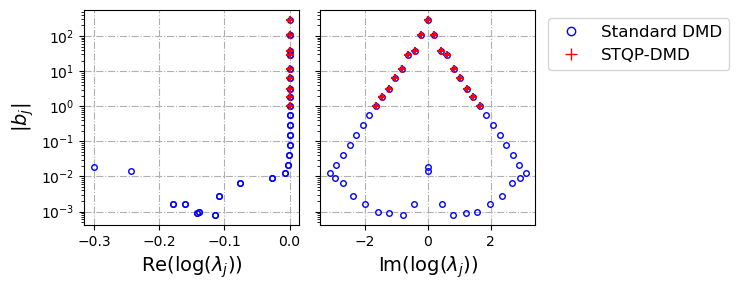

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3), sharey='row')
plt.subplots_adjust(wspace=0.2, hspace=0.2) 

axes[0].plot(np.real(np.log(exact_dmd.eigs)), np.absolute(exact_dmd._b), 
               'bo', markerfacecolor='none', markersize=4)
axes[0].plot(np.real(np.log(stqp_dmd.eigs)), np.absolute(stqp_dmd._b),
               'r+', markersize=6, markeredgewidth=1.5)

axes[1].plot(np.imag(np.log(exact_dmd.eigs)), np.absolute(exact_dmd._b), 
               'bo', markerfacecolor='none', markersize=4)
axes[1].plot(np.imag(np.log(stqp_dmd.eigs)), np.absolute(stqp_dmd._b),
               'r+', markersize=6, markeredgewidth=1.5)    

for idx in [0,1]:
    axes[idx].grid(True, linestyle='-.')
    axes[idx].set_yscale('log')
    axes[idx].set_aspect(1./axes[idx].get_data_ratio())  # Make square
    
axes[0].set_xlabel("Re(log($\lambda_j$))", fontsize=AXIS_LABEL_SIZE)
axes[1].set_xlabel("Im(log($\lambda_j$))", fontsize=AXIS_LABEL_SIZE)
    
axes[0].set_ylabel("$|b_j|$", fontsize=AXIS_LABEL_SIZE)

handles = [
    plt.Line2D([], [], marker='o', mec='b', mfc='none', linestyle='none', markersize=6),
    plt.Line2D([], [], marker='+', mec='r', mfc='r', linestyle='none', markersize=8)
]

axes[1].legend(handles, ["Standard DMD", "STQP-DMD"], bbox_to_anchor=(1.02, 1), 
                loc='upper left', fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.show()

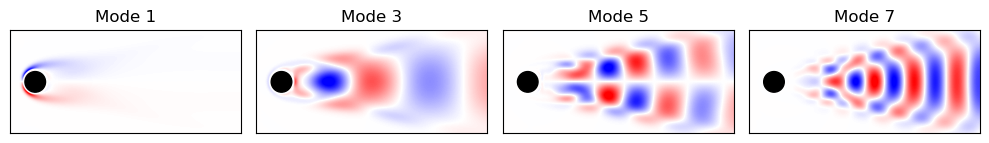

In [10]:
n_mode = np.arange(0, 8, 2)  # [0, 2, 4, 6, 8, 10, 12, 14]
fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

for i in range(4):
    mode_idx = n_mode[i]
    mode = np.real(stqp_dmd.modes[:, mode_idx].copy().reshape((nx, ny)).T)
    vmax = np.absolute(mode).max()*0.9

    im = ax[i].imshow(mode, extent=[0, xlim, 0, ylim], 
                        cmap='bwr', vmin=-vmax, vmax=vmax)
    ax[i].add_patch(Circle((cx, cy), radius, color='black', zorder=10))

    ax[i].set_aspect('equal')
    ax[i].set_title(f"Mode {(n_mode[i] + 1)}", fontsize=LEGEND_SIZE)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()

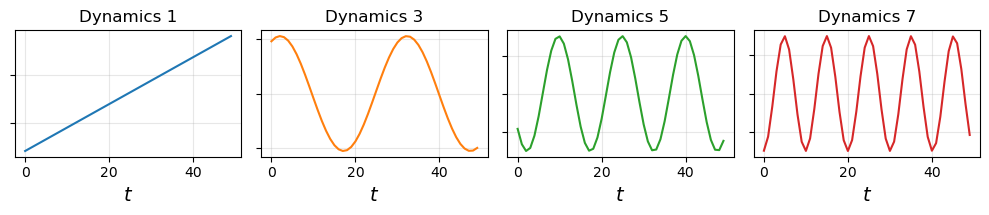

In [11]:
tab10_hex = [mcolors.rgb2hex(color) for color in plt.cm.tab10.colors]
tab10_hex

n_mode = np.arange(0, 8, 2)  
main_color = "#2ca02c" 

fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

for i in range(4):
    dyn_idx = n_mode[i]

    ax[i].plot(stqp_dmd.dynamics[dyn_idx, :].real,
                           color=tab10_hex[i], linestyle='-', label='STQP-DMD')
#     ax[i].plot(exact_dmd.dynamics[dyn_idx, :].real,
#                            color=tab10_hex[i], linestyle='dashed', label='Standard DMD')
    ax[i].set_title(f"Dynamics {(n_mode[i] + 1)}", fontsize=LEGEND_SIZE)
    ax[i].set_xlabel("$t$", fontsize=AXIS_LABEL_SIZE)
    ax[i].set_ylabel("") 
    ax[i].set_yticklabels([]) 
    ax[i].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.1, 1, 1]) 
plt.show()